In [1]:
import requests_cache
requests_cache.install_cache("cache.sqlite", backend="sqlite")
import requests # Making web requests
import pandas as pd # Tabular data operations
import geopandas as gpd # Geospatial data
import numpy as np
import folium
from dotenv import load_dotenv
load_dotenv()
import os
from tqdm.auto import tqdm
from pprint import pprint
import statsmodels.formula.api as smf
pd.set_option("display.max_columns", None)

In [2]:
results = []
s = requests.Session()
s.headers.update({"X-API-Key": os.getenv("HEALTHPOINT_API_KEY")})
r = s.get("https://api.healthpointapi.com/baseR4/HealthcareService?branch-code=pharmacy&_count=200").json() # Max 200 per page
results.extend(r["entry"])
for page in tqdm(range(200, r["total"], 200)):
    next_url = r["link"][1]["url"]
    r = s.get(next_url).json()
    results.extend(r["entry"])

  0%|          | 0/5 [00:00<?, ?it/s]

In [3]:
locations = []
for r in tqdm(results):
    r = r["resource"]
    hours = 0
    for day in r.get("availableTime", [])[:7]:
        hours += (pd.Timedelta(day["availableEndTime"]) - pd.Timedelta(day["availableStartTime"])).seconds / 60 / 60
    location = {
        "name": r["name"],
        "openHoursPerWeek": hours,
        "ECP": False,
    }
    for e in r["extension"][0]["extension"]:
        if e["url"] == "dhb-region":
            location["dhb-region"] = e["valueString"]
        if e["url"] == "services-provided":
            for service in e["extension"]:
                if service.get("valueString") == 'Emergency contraceptive pill (ECP) | Morning after pill':
                    location["ECP"] = True
        for ee in e.get("extension", []):
            if ee["url"] == "coordinates":
                for eee in ee["extension"]:
                    if eee["url"] == "latitude":
                        location["latitude"] = float(eee["valueDecimal"])
                    if eee["url"] == "longitude":
                        location["longitude"] = float(eee["valueDecimal"])
    if "latitude" not in location or "longitude" not in location:
        print("No coordinates for", r["name"])
        continue
    locations.append(location)

df = pd.DataFrame(locations)
# These are either hospital pharmacies or inpatient services
# or other services that are not relevant to the public
df = df[~df.name.str.contains("Gisborne Hospital Pharmacy|Tauranga Hospital|Hawke's Bay Hospital Pharmacy|Inpatient|Pharmacy Services", case=False)]
display(df)
df.ECP.value_counts()

  0%|          | 0/1103 [00:00<?, ?it/s]

No coordinates for ZOOM Pharmacy
No coordinates for Bargain Chemist Archers
No coordinates for Wyndham Prescription Centre
No coordinates for Chemist Warehouse Online – Covid Antivirals
No coordinates for Unichem Dennis Hanna Pharmacy
No coordinates for PillDrop Pharmacy
No coordinates for Chemist Warehouse Pukekohe - The Zone
No coordinates for NorthWest 7 Day Pharmacy


,name,openHoursPerWeek,ECP,dhb-region,latitude,longitude
0,Unichem Flagstaff Pharmacy,49.0,True,Waikato,-37.738107,175.252744
1,Unichem Invercargill Pharmacy,61.0,True,Southern,-46.412039,168.348299
2,Ngatea Pharmacy Ltd,40.0,True,Waikato,-37.275916,175.496446
3,Chemist Warehouse Taupō,91.0,True,Lakes,-38.686280,176.074909
4,Crofton Downs Pharmacy,54.0,True,Wellington,-41.257035,174.765789
...,...,...,...,...,...,...
1089,Unichem Terrace End Pharmacy,40.0,True,MidCentral,-40.347975,175.626009
1090,Waltham Pharmacy,42.5,True,Canterbury,-43.550426,172.646471
1091,Peak Pharmacy,49.0,True,Hawkes Bay,-39.667226,176.879651
1092,Victory Square Pharmacy,42.5,True,Nelson Marlborough,-41.280521,173.269706


ECP
True     1011
False      71
Name: count, dtype: int64

In [4]:
df["dhb-region"].replace({'Bay of Plenty': 'Bay of Plenty',
 'CM Health': 'Counties Manukau',
 'Canterbury': 'Canterbury',
 'Central Auckland': 'Auckland',
 'Hawkes Bay': "Hawke's Bay",
 'Hutt': 'Capital, Coast and Hutt Valley',
 'Lakes': 'Lakes',
 'MidCentral': 'MidCentral',
 'Nelson Marlborough': 'Nelson Marlborough',
 'Northland': 'Northland',
 'South Canterbury': 'South Canterbury',
 'Southern': 'Southern',
 'Tairawhiti': 'Tairāwhiti',
 'Taranaki': 'Taranaki',
 'Waikato': 'Waikato',
 'Wairarapa': 'Wairarapa',
 'Waitematā DHB': 'Waitematā',
 'Wellington': 'Capital, Coast and Hutt Valley', # Note this merges Wellington and Hutt Valley
 'West Coast': 'West Coast',
 'Whanganui': 'Whanganui'
}, inplace=True)

/tmp/ipykernel_273993/3370469065.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["dhb-region"].replace({'Bay of Plenty': 'Bay of Plenty',


In [5]:
df["depot"] = df.name.str.contains("Depot", case=False).replace({True: "Depot", False: "Community"})
depot_by_DHB = df.groupby("dhb-region").depot.value_counts().unstack().fillna(0).astype(int).T
depot_by_DHB

dhb-region,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
depot,,,,,,,,,,,,,,,,,,,
Community,134,59,137,88,119,36,21,31,30,35,11,82,7,26,86,8,133,4,15
Depot,0,0,1,0,0,0,1,1,2,1,0,3,9,1,0,0,0,0,1


In [6]:
df[["depot", "ECP"]].value_counts()

depot      ECP  
Community  True     1011
           False      51
Depot      False      20
Name: count, dtype: int64

In [7]:
openHoursStats = df.groupby("dhb-region").openHoursPerWeek.describe().T
openHoursStats.index = "Open hours per week " + openHoursStats.index
openHoursStats

dhb-region,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Open hours per week count,134.000000,59.000000,138.000000,88.000000,119.000000,36.000000,22.000000,32.000000,32.000000,36.000000,11.000000,85.000000,16.000000,27.000000,86.000000,8.000000,133.000000,4.000000,16.000000
Open hours per week mean,56.750622,51.563559,54.070652,54.690341,56.365546,51.951389,53.920455,47.611979,50.453125,49.027778,51.090909,51.772549,23.250000,49.444444,51.360465,53.687500,58.877820,47.250000,49.062500
Open hours per week std,15.152812,11.391693,14.117210,12.251730,17.173676,11.207430,15.634856,7.307616,10.063796,12.058456,10.145980,13.462306,28.439995,11.254344,13.132952,9.724555,14.005837,1.443376,9.012722
Open hours per week min,20.000000,40.000000,0.000000,35.000000,0.000000,40.000000,39.000000,40.000000,40.000000,25.500000,42.500000,34.166667,0.000000,37.500000,37.500000,42.000000,40.000000,45.500000,40.000000
Open hours per week 25%,46.125000,44.875000,45.000000,46.000000,45.000000,44.687500,45.000000,42.500000,45.000000,43.750000,45.250000,42.500000,0.000000,43.500000,44.250000,46.250000,48.500000,46.625000,42.500000
Open hours per week 50%,52.000000,48.500000,48.750000,51.500000,51.500000,49.000000,46.375000,45.000000,47.750000,48.000000,48.000000,47.500000,0.000000,48.000000,47.875000,52.250000,54.000000,47.250000,45.000000
Open hours per week 75%,63.000000,54.500000,59.000000,58.000000,65.500000,56.125000,57.750000,48.000000,52.500000,49.062500,52.750000,57.000000,47.500000,48.500000,51.000000,62.250000,67.500000,47.875000,54.250000
Open hours per week max,101.000000,91.000000,91.000000,94.500000,105.000000,91.000000,91.000000,69.000000,84.000000,91.000000,75.000000,98.000000,73.000000,91.000000,98.000000,66.000000,101.500000,49.000000,70.500000


In [8]:
ECP = df.groupby(["dhb-region"]).ECP.value_counts().unstack().fillna(0).astype(int).rename(columns={True: "ECP", False: "No ECP"}).T.sort_index()
ECP

dhb-region,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
ECP,,,,,,,,,,,,,,,,,,,
ECP,126,56,130,83,116,32,20,31,29,33,10,78,7,25,84,8,126,4,13
No ECP,8,3,8,5,3,4,2,1,3,3,1,7,9,2,2,0,7,0,3


In [9]:
results = pd.concat([depot_by_DHB, openHoursStats, ECP])
results

dhb-region,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Community,134.000000,59.000000,137.000000,88.000000,119.000000,36.000000,21.000000,31.000000,30.000000,35.000000,11.000000,82.000000,7.000000,26.000000,86.000000,8.000000,133.000000,4.000000,15.000000
Depot,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,1.000000,0.000000,3.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
Open hours per week count,134.000000,59.000000,138.000000,88.000000,119.000000,36.000000,22.000000,32.000000,32.000000,36.000000,11.000000,85.000000,16.000000,27.000000,86.000000,8.000000,133.000000,4.000000,16.000000
Open hours per week mean,56.750622,51.563559,54.070652,54.690341,56.365546,51.951389,53.920455,47.611979,50.453125,49.027778,51.090909,51.772549,23.250000,49.444444,51.360465,53.687500,58.877820,47.250000,49.062500
Open hours per week std,15.152812,11.391693,14.117210,12.251730,17.173676,11.207430,15.634856,7.307616,10.063796,12.058456,10.145980,13.462306,28.439995,11.254344,13.132952,9.724555,14.005837,1.443376,9.012722
Open hours per week min,20.000000,40.000000,0.000000,35.000000,0.000000,40.000000,39.000000,40.000000,40.000000,25.500000,42.500000,34.166667,0.000000,37.500000,37.500000,42.000000,40.000000,45.500000,40.000000
Open hours per week 25%,46.125000,44.875000,45.000000,46.000000,45.000000,44.687500,45.000000,42.500000,45.000000,43.750000,45.250000,42.500000,0.000000,43.500000,44.250000,46.250000,48.500000,46.625000,42.500000
Open hours per week 50%,52.000000,48.500000,48.750000,51.500000,51.500000,49.000000,46.375000,45.000000,47.750000,48.000000,48.000000,47.500000,0.000000,48.000000,47.875000,52.250000,54.000000,47.250000,45.000000
Open hours per week 75%,63.000000,54.500000,59.000000,58.000000,65.500000,56.125000,57.750000,48.000000,52.500000,49.062500,52.750000,57.000000,47.500000,48.500000,51.000000,62.250000,67.500000,47.875000,54.250000
Open hours per week max,101.000000,91.000000,91.000000,94.500000,105.000000,91.000000,91.000000,69.000000,84.000000,91.000000,75.000000,98.000000,73.000000,91.000000,98.000000,66.000000,101.500000,49.000000,70.500000


In [10]:
df.to_csv("healthpoint_pharmacies_ECP.csv", index=False)

In [11]:
df = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs=4326)
df

,name,openHoursPerWeek,ECP,dhb-region,latitude,longitude,depot,geometry
0,Unichem Flagstaff Pharmacy,49.0,True,Waikato,-37.738107,175.252744,Community,POINT (175.25274 -37.73811)
1,Unichem Invercargill Pharmacy,61.0,True,Southern,-46.412039,168.348299,Community,POINT (168.3483 -46.41204)
2,Ngatea Pharmacy Ltd,40.0,True,Waikato,-37.275916,175.496446,Community,POINT (175.49645 -37.27592)
3,Chemist Warehouse Taupō,91.0,True,Lakes,-38.686280,176.074909,Community,POINT (176.07491 -38.68628)
4,Crofton Downs Pharmacy,54.0,True,"Capital, Coast and Hutt Valley",-41.257035,174.765789,Community,POINT (174.76579 -41.25704)
...,...,...,...,...,...,...,...,...
1089,Unichem Terrace End Pharmacy,40.0,True,MidCentral,-40.347975,175.626009,Community,POINT (175.62601 -40.34797)
1090,Waltham Pharmacy,42.5,True,Canterbury,-43.550426,172.646471,Community,POINT (172.64647 -43.55043)
1091,Peak Pharmacy,49.0,True,Hawke's Bay,-39.667226,176.879651,Community,POINT (176.87965 -39.66723)
1092,Victory Square Pharmacy,42.5,True,Nelson Marlborough,-41.280521,173.269706,Community,POINT (173.26971 -41.28052)


In [12]:
sa2 = gpd.read_file("statistical-area-2-2023-generalised_simplified_22.3%.zip").dropna(subset="geometry")
sa2 = sa2[(sa2.SA22023__1 != "Chatham Islands") & (sa2.LAND_AREA_ > 0)].copy()
sa2

,SA22023_V1,SA22023__1,SA22023__2,LAND_AREA_,AREA_SQ_KM,Shape_Leng,geometry
0,100100,North Cape,North Cape,829.188012,829.188012,416039.151064,"MULTIPOLYGON (((1614055.808 6154067.023, 16141..."
1,100200,Rangaunu Harbour,Rangaunu Harbour,274.004295,274.004295,149089.110095,"MULTIPOLYGON (((1624166.328 6127258.658, 16243..."
3,100400,Karikari Peninsula,Karikari Peninsula,174.440751,174.440751,140149.099270,"MULTIPOLYGON (((1626838.499 6126965.133, 16270..."
4,100500,Tangonge,Tangonge,177.182117,177.182117,101466.900183,"POLYGON ((1623516.265 6119580.907, 1623492.213..."
5,100900,Rangitihi,Rangitihi,84.539982,84.539982,60636.302194,"POLYGON ((1629314.862 6117970.968, 1629371.783..."
...,...,...,...,...,...,...,...
2374,362601,Heidelberg,Heidelberg,1.308968,1.308968,5367.870180,"POLYGON ((1245892.259 4848174.153, 1245922.973..."
2375,363001,Clifton-Kew,Clifton-Kew,3.770832,3.770832,11890.253381,"POLYGON ((1243666.689 4847254.124, 1243677.447..."
2376,363100,Woodend-Greenhills,Woodend-Greenhills,173.600766,173.600766,166674.352079,"MULTIPOLYGON (((1248612.765 4823630.51, 124866..."
2378,363301,Bluff,Bluff,10.136949,10.290040,23162.004392,"POLYGON ((1244729.237 4827495.819, 1244667.973..."


In [13]:
BASE_URL = "http://osrm.auckland-cer.cloud.edu.au"

def drive(from_points, to_points):
    from_points_s = ";".join([f"{point.x},{point.y}" for point in from_points])
    from_indices = ";".join([str(i) for i in range(len(from_points))])
    to_points_s = ";".join([f"{point.x},{point.y}" for point in to_points])
    to_indices = ";".join([str(i + len(from_points)) for i in range(len(to_points))])
    result = requests.get(f"{BASE_URL}/table/v1/driving/{from_points_s};{to_points_s}?sources={from_indices}&destinations={to_indices}&annotations=duration,distance")
    return result.json()
result = drive(from_points=sa2.centroid.to_crs(epsg=4326), to_points=df.geometry.to_crs(epsg=4326))
ECP_result = drive(from_points=sa2.centroid.to_crs(epsg=4326), to_points=df[df.ECP].geometry.to_crs(epsg=4326))

In [14]:
min_indices = np.argmin(result["distances"], axis=1)
min_indices_ECP = np.argmin(ECP_result["distances"], axis=1)
sa2["Distance to nearest pharmacy (m)"] = [result["distances"][i][min_indices[i]] for i in range(len(min_indices))]
sa2["Distance to nearest ECP pharmacy (m)"] = [ECP_result["distances"][i][min_indices_ECP[i]] for i in range(len(min_indices_ECP))]
sa2["Travel time to nearest pharmacy (s)"] = [result["durations"][i][min_indices[i]] for i in range(len(min_indices))]
sa2["Travel time to nearest ECP pharmacy (s)"] = [ECP_result["durations"][i][min_indices_ECP[i]] for i in range(len(min_indices_ECP))]
sa2["Nearest pharmacy name"] = list(df.name.iloc[min_indices])
sa2["Nearest ECP pharmacy name"] = list(df[df.ECP].name.iloc[min_indices_ECP])
sa2["DHB"] = list(df[df.ECP]["dhb-region"].iloc[min_indices_ECP])
sa2["openHoursPerWeek"] = list(df[df.ECP].openHoursPerWeek.iloc[min_indices_ECP])

In [15]:
distance_time_stats = sa2.groupby("DHB")[["Distance to nearest pharmacy (m)", "Distance to nearest ECP pharmacy (m)", "Travel time to nearest pharmacy (s)", "Travel time to nearest ECP pharmacy (s)"]].describe().T
distance_time_stats

DHB                                                Auckland  Bay of Plenty  \
Distance to nearest pharmacy (m)        count    181.000000     109.000000   
                                        mean    1132.825967    6235.494495   
                                        std     2402.470948   11586.083148   
                                        min        4.300000     129.100000   
                                        25%      516.500000    1095.300000   
                                        50%      841.700000    2167.000000   
                                        75%     1171.100000    6273.200000   
                                        max    29252.900000   81058.800000   
Distance to nearest ECP pharmacy (m)    count    181.000000     109.000000   
                                        mean    1162.341989    6239.520183   
                                        std     2400.562975   11584.158615   
                                        min        4.300000     129.100000   
                                        25%      534.700000    1095.300000   
                                        50%      864.100000    2167.000000   
                                        75%     1246.800000    6273.200000   
                                        max    29252.900000   81058.800000   
Travel time to nearest pharmacy (s)     count    181.000000     109.000000   
                                        mean     127.728729     599.399083   
                                        std      250.511838    1015.710279   
                                        min        0.500000      11.700000   
                                        25%       69.100000     131.500000   
                                        50%       97.900000     222.300000   
                                        75%      134.200000     545.200000   
                                        max     3175.500000    6458.100000   
Travel time to nearest ECP pharmacy (s) count    181.000000     109.000000   
                                        mean     130.166851     599.760550   
                                        std      250.266598    1015.532553   
                                        min        0.500000      11.700000   
                                        25%       70.700000     131.500000   
                                        50%      102.600000     222.300000   
                                        75%      140.600000     545.200000   
                                        max     3175.500000    6458.100000   

DHB                                               Canterbury  \
Distance to nearest pharmacy (m)        count     279.000000   
                                        mean     5003.850896   
                                        std     10748.432797   
                                        min         4.000000   
                                        25%       716.200000   
                                        50%      1325.900000   
                                        75%      3049.850000   
                                        max     88348.200000   
Distance to nearest ECP pharmacy (m)    count     279.000000   
                                        mean     6068.725806   
                                        std     14321.081318   
                                        min         4.000000   
                                        25%       848.050000   
                                        50%      1377.500000   
                                        75%      3446.150000   
                                        max    102439.800000   
Travel time to nearest pharmacy (s)     count     279.000000   
                                        mean      393.377778   
                                        std       714.332437   
                                        min         1.000000   
                                        25%       101.250000   
                 

In [16]:
distance_time_stats.index.names = ["Metric", "Statistic"]

<Axes: xlabel='DHB'>

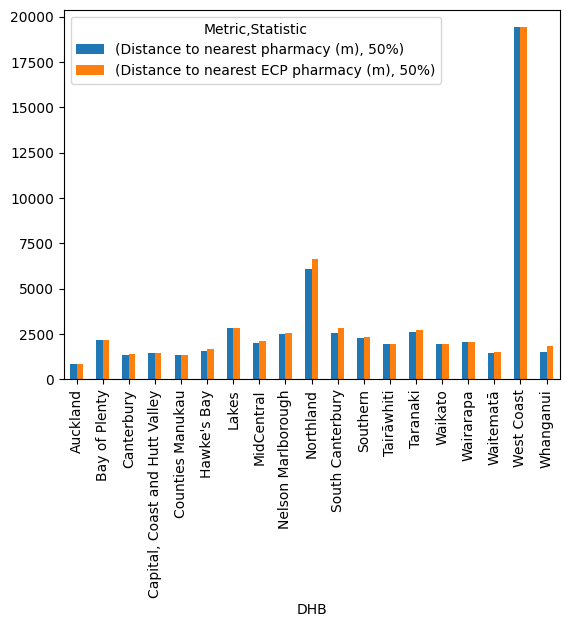

In [17]:
distance_time_stats.loc[[('Distance to nearest pharmacy (m)', '50%'), ('Distance to nearest ECP pharmacy (m)', '50%')]].T.plot.bar()

In [18]:
distance_time_stats.loc[('Distance to nearest ECP pharmacy (m)', '50%')] - distance_time_stats.loc[('Distance to nearest pharmacy (m)', '50%')]

DHB
Auckland                           22.40
Bay of Plenty                       0.00
Canterbury                         51.60
Capital, Coast and Hutt Valley     30.15
Counties Manukau                    8.80
Hawke's Bay                       113.45
Lakes                               0.00
MidCentral                        112.00
Nelson Marlborough                 49.00
Northland                         543.10
South Canterbury                  244.50
Southern                           51.35
Tairāwhiti                          0.00
Taranaki                          153.60
Waikato                             7.80
Wairarapa                           0.00
Waitematā                          60.80
West Coast                          0.00
Whanganui                         322.40
dtype: float64

In [19]:
distance_time_stats.loc[('Travel time to nearest ECP pharmacy (s)', '50%')] - distance_time_stats.loc[('Travel time to nearest pharmacy (s)', '50%')]

DHB
Auckland                           4.70
Bay of Plenty                      0.00
Canterbury                         4.80
Capital, Coast and Hutt Valley     1.40
Counties Manukau                   0.30
Hawke's Bay                       17.90
Lakes                              0.00
MidCentral                         5.35
Nelson Marlborough                 1.30
Northland                         15.40
South Canterbury                  35.20
Southern                           5.05
Tairāwhiti                         0.00
Taranaki                          39.90
Waikato                            1.80
Wairarapa                          0.00
Waitematā                          3.00
West Coast                         0.00
Whanganui                         18.00
dtype: float64

<Axes: xlabel='DHB'>

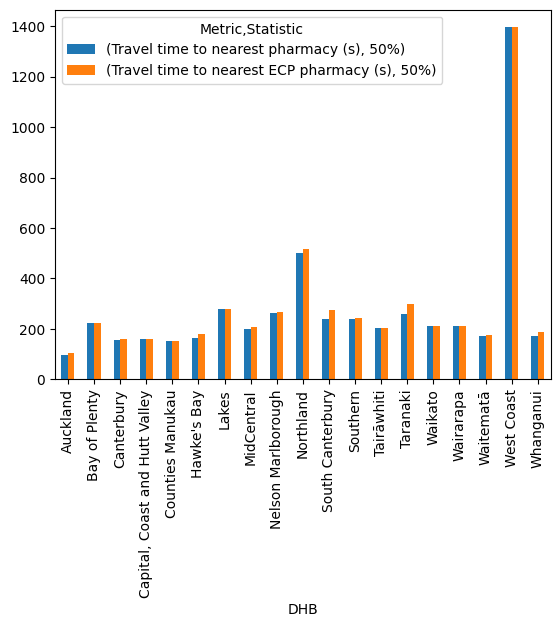

In [20]:
distance_time_stats.loc[[('Travel time to nearest pharmacy (s)', '50%'), ('Travel time to nearest ECP pharmacy (s)', '50%')]].T.plot.bar()

In [21]:
pop = pd.read_csv("2023 population by DHB.csv")
pop["Sex at birth"] = np.where(pop["CEN23_SAB_002"] == 11, "Male", "Female")
fpop = pop[pop["Sex at birth"] == "Female"]
pop

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,CEN23_YEAR_001,Census year,CEN23_GEO_002,Area,CEN23_ETH_002,Ethnicity,CEN23_AGE_001,Age,CEN23_SAB_002,Sex at birth,OBS_VALUE,Observation Value,OBS_STATUS,Observation Status
0,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,4,15-19 years,11,Male,5952,NaN,NaN,NaN
1,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,4,15-19 years,22,Female,5583,NaN,NaN,NaN
2,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,5,20-24 years,11,Male,4485,NaN,NaN,NaN
3,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,5,20-24 years,22,Female,4158,NaN,NaN,NaN
4,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,6,25-29 years,11,Male,4845,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,404,Southern,999,Total - ethnicity,12,55-59 years,22,Female,10938,NaN,NaN,NaN
414,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,404,Southern,999,Total - ethnicity,13,60-64 years,11,Male,10818,NaN,NaN,NaN
415,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,404,Southern,999,Total - ethnicity,13,60-64 years,22,Female,11208,NaN,NaN,NaN
416,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,404,Southern,999,Total - ethnicity,4,65 years and over,11,Male,29445,NaN,NaN,NaN


In [22]:
fpop_by_dhb = fpop.pivot_table(index="Age", columns="Area", values="OBS_VALUE", aggfunc="sum")
fpop_by_dhb

Area,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Age,,,,,,,,,,,,,,,,,,,
15-19 years,14706,7629,18234,15450,20253,5409,3540,5793,4206,5583,1557,12273,1689,3636,13950,1368,18909,741,1947
20-24 years,19185,6156,18504,17871,19149,4200,2829,5616,3102,4158,1278,12606,1353,2895,12855,975,17826,621,1581
25-29 years,21384,7524,19518,17355,21450,4905,3474,5787,3894,4836,1620,10755,1572,3312,13842,1236,20526,774,1881
30-34 years,20961,9162,22611,18645,24252,5856,3975,6273,4902,5910,1944,12063,1695,4158,15885,1515,25182,1029,2160
35-39 years,17883,8664,20394,16830,22185,5160,3759,5730,4893,5610,1692,11259,1635,4194,14535,1338,25413,876,1959
40-44 years,15771,7938,18684,15564,19842,5058,3384,5277,4791,5115,1662,10368,1482,3822,13260,1473,23334,870,1752
45-49 years,14838,8022,18336,15216,17547,5406,3480,5322,5061,5520,1758,10230,1431,3963,12792,1488,20889,1014,1917
50-54 years,15327,8706,20061,15912,18225,6030,3810,6000,5853,6615,2100,11097,1617,4260,13968,1791,21339,1275,2244
55-59 years,13476,8304,18651,14445,16404,5784,3777,5898,5931,7050,2244,10938,1581,4029,13167,1788,19029,1386,2388


In [23]:
aggregate = fpop_by_dhb.loc["45-49":"65 years and over"].sum(axis=0).sort_values(ascending=False)
aggregate.name = "45 years and over"
fpop_by_dhb = pd.concat([fpop_by_dhb.loc[:"45-49"], aggregate.to_frame().T])
fpop_by_dhb.index = "Female " + fpop_by_dhb.index
fpop_by_dhb

Area,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Female 15-19 years,14706,7629,18234,15450,20253,5409,3540,5793,4206,5583,1557,12273,1689,3636,13950,1368,18909,741,1947
Female 20-24 years,19185,6156,18504,17871,19149,4200,2829,5616,3102,4158,1278,12606,1353,2895,12855,975,17826,621,1581
Female 25-29 years,21384,7524,19518,17355,21450,4905,3474,5787,3894,4836,1620,10755,1572,3312,13842,1236,20526,774,1881
Female 30-34 years,20961,9162,22611,18645,24252,5856,3975,6273,4902,5910,1944,12063,1695,4158,15885,1515,25182,1029,2160
Female 35-39 years,17883,8664,20394,16830,22185,5160,3759,5730,4893,5610,1692,11259,1635,4194,14535,1338,25413,876,1959
Female 40-44 years,15771,7938,18684,15564,19842,5058,3384,5277,4791,5115,1662,10368,1482,3822,13260,1473,23334,870,1752
Female 45 years and over,88887,62766,128262,95211,103533,41454,25371,42252,41907,48228,15528,75681,10770,29277,93666,13026,128847,8757,16707


In [24]:
sex_by_DHB = pop.pivot_table(index="Sex at birth", columns="Area", values="OBS_VALUE", aggfunc="sum")
sex_by_DHB

Area,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Sex at birth,,,,,,,,,,,,,,,,,,,
Female,198777,109839,246207,196926,230664,72042,46332,76728,67695,79440,25281,145005,20196,51294,177993,20931,260037,13668,27987
Male,192339,102714,239754,185472,225744,68304,44427,72618,65685,76494,24963,140973,19551,49413,171429,19719,249711,14268,26814


In [25]:
DHB = gpd.read_file("DHB_with_weighted_average_IMD18.shp.zip")
DHB = DHB[DHB.DHB2015_Co != "99"]
DHB

,DHB2015_Co,DHB2015_Na,Shape_Leng,Census_Pop,Count_DZ20,Rank_IMD18,Rank_Emplo,Rank_Incom,Rank_Crime,Rank_Housi,Rank_Healt,Rank_Educa,Rank_Acces,geometry
0,01,Northland,1.651929e+06,179277.0,233.0,4186.139929,4408.972314,4102.090865,3550.266454,3374.030004,2976.975702,4427.724443,4541.327783,"MULTIPOLYGON (((1714357.617 5983211.997, 17143..."
1,02,Waitemata,9.273920e+05,586419.0,766.0,2555.370481,2534.364779,2838.310897,2377.956905,3196.632655,2925.216122,2275.860630,3072.006252,"MULTIPOLYGON (((1733681.085 5898435.008, 17336..."
2,03,Auckland,7.781903e+05,468210.0,600.0,2657.051784,2612.240652,2490.958480,3543.322157,4213.631390,3095.427071,1752.652656,1556.293362,"MULTIPOLYGON (((1792135.131 5911180.463, 17921..."
3,04,Counties Manukau,6.642233e+05,538047.0,673.0,3605.304925,3163.296191,3680.218881,3357.409899,4132.371053,3840.297855,3726.701632,2394.369704,"POLYGON ((1770832.38 5917413.866, 1770841.514 ..."
4,05,Waikato,1.498296e+06,406302.0,535.0,3841.634996,3718.750059,3601.131466,3475.211550,3334.801985,3609.067494,3853.276098,3640.353028,"MULTIPOLYGON (((1857357.606 5876615.882, 18573..."
5,06,Lakes,6.236689e+05,109350.0,142.0,3932.881481,3886.664417,3705.677641,3867.164472,3342.953032,3543.913224,3955.365569,3424.880713,"POLYGON ((1888813.981 5796074.319, 1888957.483..."
6,07,Bay of Plenty,9.468737e+05,240525.0,307.0,3424.531662,3444.681902,3303.093957,3364.163106,2739.652897,3231.519414,3613.792679,3805.321123,"MULTIPOLYGON (((1881976.181 5830239.392, 18819..."
7,08,Tairawhiti,6.895486e+05,47619.0,65.0,4529.040509,4442.164777,4519.621937,4054.131859,4027.701569,3930.705664,4461.959869,3422.965917,"MULTIPOLYGON (((2039187 5703721.815, 2039193.6..."
8,09,Taranaki,5.657958e+05,117957.0,158.0,3546.936316,3622.695287,3558.354434,2691.329128,2515.897581,3463.655739,3990.581983,3657.769806,"MULTIPOLYGON (((1687624.521 5675968.386, 16876..."
9,10,Hawke's Bay,9.454397e+05,166491.0,223.0,3594.516406,3398.434267,3770.723084,3810.380597,3205.178730,3213.648594,3686.793394,2881.920356,"MULTIPOLYGON (((1941251.295 5580353.81, 194124..."


In [26]:
import rapidfuzz

mapping = {dhb: rapidfuzz.process.extractOne(dhb, sex_by_DHB.columns)[0] for dhb in DHB.DHB2015_Na}
mapping

{'Northland': 'Northland',
 'Waitemata': 'Waitematā',
 'Auckland': 'Auckland',
 'Counties Manukau': 'Counties Manukau',
 'Waikato': 'Waikato',
 'Lakes': 'Lakes',
 'Bay of Plenty': 'Bay of Plenty',
 'Tairawhiti': 'Tairāwhiti',
 'Taranaki': 'Taranaki',
 "Hawke's Bay": "Hawke's Bay",
 'Whanganui': 'Whanganui',
 'MidCentral': 'MidCentral',
 'Hutt Valley': 'Capital, Coast and Hutt Valley',
 'Capital and Coast': 'Capital, Coast and Hutt Valley',
 'Wairarapa': 'Wairarapa',
 'Nelson Marlborough': 'Nelson Marlborough',
 'West Coast': 'West Coast',
 'Canterbury': 'Canterbury',
 'South Canterbury': 'South Canterbury',
 'Southern': 'Southern'}

In [27]:
DHB.DHB2015_Na.replace(mapping, inplace=True)

/tmp/ipykernel_273993/3327784085.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  DHB.DHB2015_Na.replace(mapping, inplace=True)


In [28]:
subset = DHB[DHB.DHB2015_Na == "Capital, Coast and Hutt Valley"].copy()
subset

,DHB2015_Co,DHB2015_Na,Shape_Leng,Census_Pop,Count_DZ20,Rank_IMD18,Rank_Emplo,Rank_Incom,Rank_Crime,Rank_Housi,Rank_Healt,Rank_Educa,Rank_Acces,geometry
12,13,"Capital, Coast and Hutt Valley",210698.311189,148800.0,199.0,3363.140282,3735.870615,3257.820625,2987.432823,2936.014133,3557.293105,3208.616452,2878.234899,"MULTIPOLYGON (((1756698.08 5427011.835, 175671..."
13,14,"Capital, Coast and Hutt Valley",292386.786264,304551.0,411.0,2278.799265,2867.579002,2261.305584,2448.044170,2865.607150,2453.113597,1626.578337,2544.561807,"MULTIPOLYGON (((1748455.496 5421016.325, 17484..."


In [29]:
merged_data = {
    "DHB2015_Co": subset.DHB2015_Co.iloc[0],
    "DHB2015_Na": subset.DHB2015_Na.iloc[0],
    "geometry": subset.union_all(),
    "Count_DZ20": subset.Count_DZ20.sum(),
}
for col in subset.columns[subset.columns.str.startswith("Rank_")]:
    # Average, weighted by Census_Pop
    merged_data[col] = (subset.Census_Pop * subset[col]).sum() / subset.Census_Pop.sum()
DHB = pd.concat((DHB[DHB.DHB2015_Na != "Capital, Coast and Hutt Valley"], pd.Series(merged_data).to_frame().T))
DHB

,DHB2015_Co,DHB2015_Na,Shape_Leng,Census_Pop,Count_DZ20,Rank_IMD18,Rank_Emplo,Rank_Incom,Rank_Crime,Rank_Housi,Rank_Healt,Rank_Educa,Rank_Acces,geometry
0,01,Northland,1.651929e+06,179277.0,233.0,4186.139929,4408.972314,4102.090865,3550.266454,3374.030004,2976.975702,4427.724443,4541.327783,"MULTIPOLYGON (((1714357.617 5983211.997, 17143..."
1,02,Waitematā,9.273920e+05,586419.0,766.0,2555.370481,2534.364779,2838.310897,2377.956905,3196.632655,2925.216122,2275.86063,3072.006252,"MULTIPOLYGON (((1733681.085 5898435.008, 17336..."
2,03,Auckland,7.781903e+05,468210.0,600.0,2657.051784,2612.240652,2490.95848,3543.322157,4213.63139,3095.427071,1752.652656,1556.293362,"MULTIPOLYGON (((1792135.131 5911180.463, 17921..."
3,04,Counties Manukau,6.642233e+05,538047.0,673.0,3605.304925,3163.296191,3680.218881,3357.409899,4132.371053,3840.297855,3726.701632,2394.369704,"POLYGON ((1770832.38 5917413.866, 1770841.514 ..."
4,05,Waikato,1.498296e+06,406302.0,535.0,3841.634996,3718.750059,3601.131466,3475.21155,3334.801985,3609.067494,3853.276098,3640.353028,"MULTIPOLYGON (((1857357.606 5876615.882, 18573..."
5,06,Lakes,6.236689e+05,109350.0,142.0,3932.881481,3886.664417,3705.677641,3867.164472,3342.953032,3543.913224,3955.365569,3424.880713,"POLYGON ((1888813.981 5796074.319, 1888957.483..."
6,07,Bay of Plenty,9.468737e+05,240525.0,307.0,3424.531662,3444.681902,3303.093957,3364.163106,2739.652897,3231.519414,3613.792679,3805.321123,"MULTIPOLYGON (((1881976.181 5830239.392, 18819..."
7,08,Tairāwhiti,6.895486e+05,47619.0,65.0,4529.040509,4442.164777,4519.621937,4054.131859,4027.701569,3930.705664,4461.959869,3422.965917,"MULTIPOLYGON (((2039187 5703721.815, 2039193.6..."
8,09,Taranaki,5.657958e+05,117957.0,158.0,3546.936316,3622.695287,3558.354434,2691.329128,2515.897581,3463.655739,3990.581983,3657.769806,"MULTIPOLYGON (((1687624.521 5675968.386, 16876..."
9,10,Hawke's Bay,9.454397e+05,166491.0,223.0,3594.516406,3398.434267,3770.723084,3810.380597,3205.17873,3213.648594,3686.793394,2881.920356,"MULTIPOLYGON (((1941251.295 5580353.81, 194124..."


In [30]:
average_dep_by_DHB = DHB.set_index("DHB2015_Na").Rank_IMD18
average_dep_by_DHB.name = "Average deprivation index"
average_dep_by_DHB = average_dep_by_DHB.to_frame().T
average_dep_by_DHB

DHB2015_Na,Northland,Waitematā,Auckland,Counties Manukau,Waikato,Lakes,Bay of Plenty,Tairāwhiti,Taranaki,Hawke's Bay,Whanganui,MidCentral,Wairarapa,Nelson Marlborough,West Coast,Canterbury,South Canterbury,Southern,"Capital, Coast and Hutt Valley"
Average deprivation index,4186.139929,2555.370481,2657.051784,3605.304925,3841.634996,3932.881481,3424.531662,4529.040509,3546.936316,3594.516406,4285.061644,3766.102352,3360.118786,2618.531608,3902.934363,2499.383506,2536.854829,2466.156269,2634.704388


In [31]:
births_by_DHB = pd.read_csv("WGB_DHB_table.csv")
births_by_DHB = births_by_DHB[(births_by_DHB.birth_year == 2022) & (births_by_DHB.category == "agegrp1") & (births_by_DHB.sub_category != "total") & (births_by_DHB.DHB != "Unknown")]
merged_data = pd.DataFrame({"DHB": "Capital, Coast and Hutt Valley", "number": births_by_DHB[births_by_DHB.DHB.isin(["Capital & Coast", "Hutt Valley"])].groupby("sub_category").number.sum()}).reset_index()
births_by_DHB = pd.concat((births_by_DHB[~births_by_DHB.DHB.isin(["Capital & Coast", "Hutt Valley"])], merged_data), axis=0)
births_by_DHB.DHB = births_by_DHB.DHB.replace({
  "Tairawhiti": "Tairāwhiti",
  "Waitemata": "Waitematā",
})
births_by_DHB = births_by_DHB.pivot_table(index="sub_category", columns="DHB", values="number")
births_by_DHB.index = "Number of people giving birth aged " + births_by_DHB.index
births_by_DHB = births_by_DHB.loc[[
       'Number of people giving birth aged <20',
       'Number of people giving birth aged 20-24',
       'Number of people giving birth aged 25-29',
       'Number of people giving birth aged 30-34',
       'Number of people giving birth aged 35-39',
       'Number of people giving birth aged 40+'
]]
births_by_DHB

DHB,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
sub_category,,,,,,,,,,,,,,,,,,,
Number of people giving birth aged <20,90.0,146.0,120.0,109.0,299.0,78.0,84.0,82.0,46.0,118.0,10.0,80.0,60.0,46.0,211.0,23.0,120.0,3.0,49.0
Number of people giving birth aged 20-24,400.0,422.0,647.0,463.0,1276.0,361.0,318.0,367.0,176.0,460.0,82.0,397.0,157.0,221.0,919.0,95.0,591.0,46.0,154.0
Number of people giving birth aged 25-29,932.0,861.0,1636.0,1051.0,2240.0,584.0,456.0,658.0,365.0,639.0,154.0,827.0,184.0,370.0,1536.0,179.0,1733.0,81.0,247.0
Number of people giving birth aged 30-34,1957.0,1046.0,2505.0,1787.0,2651.0,657.0,444.0,650.0,508.0,714.0,220.0,1217.0,188.0,489.0,1784.0,154.0,2872.0,109.0,226.0
Number of people giving birth aged 35-39,1280.0,568.0,1271.0,1099.0,1301.0,300.0,213.0,345.0,237.0,356.0,89.0,653.0,94.0,225.0,786.0,63.0,1664.0,43.0,115.0
Number of people giving birth aged 40+,294.0,104.0,274.0,227.0,285.0,66.0,45.0,55.0,55.0,79.0,23.0,145.0,32.0,46.0,175.0,11.0,373.0,12.0,23.0


In [32]:
results = pd.concat([depot_by_DHB, openHoursStats, ECP, distance_time_stats, fpop_by_dhb, sex_by_DHB, average_dep_by_DHB, births_by_DHB])
results.to_excel("results.xlsx", index=True)
results

,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Community,134,59,137,88,119,36,21,31,30,35,11,82,7,26,86,8,133,4,15
Depot,0,0,1,0,0,0,1,1,2,1,0,3,9,1,0,0,0,0,1
Open hours per week count,134.0,59.0,138.0,88.0,119.0,36.0,22.0,32.0,32.0,36.0,11.0,85.0,16.0,27.0,86.0,8.0,133.0,4.0,16.0
Open hours per week mean,56.750622,51.563559,54.070652,54.690341,56.365546,51.951389,53.920455,47.611979,50.453125,49.027778,51.090909,51.772549,23.25,49.444444,51.360465,53.6875,58.87782,47.25,49.0625
Open hours per week std,15.152812,11.391693,14.11721,12.25173,17.173676,11.20743,15.634856,7.307616,10.063796,12.058456,10.14598,13.462306,28.439995,11.254344,13.132952,9.724555,14.005837,1.443376,9.012722
Open hours per week min,20.0,40.0,0.0,35.0,0.0,40.0,39.0,40.0,40.0,25.5,42.5,34.166667,0.0,37.5,37.5,42.0,40.0,45.5,40.0
Open hours per week 25%,46.125,44.875,45.0,46.0,45.0,44.6875,45.0,42.5,45.0,43.75,45.25,42.5,0.0,43.5,44.25,46.25,48.5,46.625,42.5
Open hours per week 50%,52.0,48.5,48.75,51.5,51.5,49.0,46.375,45.0,47.75,48.0,48.0,47.5,0.0,48.0,47.875,52.25,54.0,47.25,45.0
Open hours per week 75%,63.0,54.5,59.0,58.0,65.5,56.125,57.75,48.0,52.5,49.0625,52.75,57.0,47.5,48.5,51.0,62.25,67.5,47.875,54.25
Open hours per week max,101.0,91.0,91.0,94.5,105.0,91.0,91.0,69.0,84.0,91.0,75.0,98.0,73.0,91.0,98.0,66.0,101.5,49.0,70.5


In [33]:
if not os.path.isfile("index.html"):
  m = sa2.explore("Distance to nearest ECP pharmacy (m)", legend=True, name="SA2s", popup=True)
  df.explore("ECP", m=m, cmap=["red", "green"], marker_kwds={"radius": 5}, popup=True, name="pharmacies")
  folium.LayerControl().add_to(m)
  m.save("index.html")
  del m

Text(161.56577304440506, 0.5, 'Latitude')

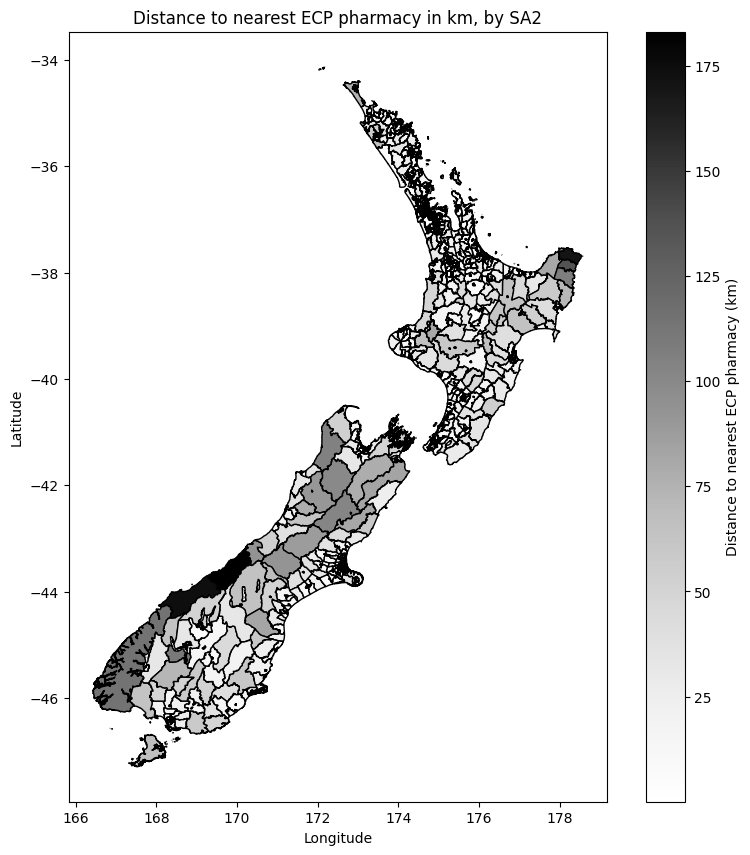

In [34]:
sa2["Distance to nearest ECP pharmacy (km)"] = sa2["Distance to nearest ECP pharmacy (m)"] / 1000
ax = sa2.to_crs(4326).plot("Distance to nearest ECP pharmacy (km)", cmap="Grays", figsize=(10,10), legend=True, edgecolor="black", legend_kwds={"label": "Distance to nearest ECP pharmacy (km)"})
ax.title.set_text("Distance to nearest ECP pharmacy in km, by SA2")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

In [35]:
pop_by_SA2 = pd.read_csv("2023 population by SA2.csv")
pop_by_SA2 = pd.pivot_table(pop_by_SA2[pop_by_SA2.CEN23_SAB_002 == 22], index="Age", columns="Area", values="OBS_VALUE", aggfunc="sum")
fpop_by_SA2_under_45 = pop_by_SA2.loc[:"40-44 years"].sum()
fpop_by_SA2_under_45.name = "Female_population_15_to_45_years"
fpop_by_SA2_under_45

Area
Abbey Caves-Glenbervie    204.0
Abbotsford                552.0
Acacia Bay                219.0
Addington East            888.0
Addington North             0.0
                          ...  
Ōwairaka East             525.0
Ōwairaka West             786.0
Ōwhata East               618.0
Ōwhata West               660.0
Ōwhiro Bay                435.0
Name: Female_population_15_to_45_years, Length: 2414, dtype: float64

In [36]:
sa2 = sa2.merge(fpop_by_SA2_under_45, left_on="SA22023__1", right_index=True)
sa2

,SA22023_V1,SA22023__1,SA22023__2,LAND_AREA_,AREA_SQ_KM,Shape_Leng,geometry,Distance to nearest pharmacy (m),Distance to nearest ECP pharmacy (m),Travel time to nearest pharmacy (s),Travel time to nearest ECP pharmacy (s),Nearest pharmacy name,Nearest ECP pharmacy name,DHB,openHoursPerWeek,Distance to nearest ECP pharmacy (km),Female_population_15_to_45_years
0,100100,North Cape,North Cape,829.188012,829.188012,416039.151064,"MULTIPOLYGON (((1614055.808 6154067.023, 16141...",73907.0,73907.0,4065.0,4065.0,Browns Community Pharmacy Kaitaia,Browns Community Pharmacy Kaitaia,Northland,48.00,73.9070,282.0
1,100200,Rangaunu Harbour,Rangaunu Harbour,274.004295,274.004295,149089.110095,"MULTIPOLYGON (((1624166.328 6127258.658, 16243...",21844.5,21844.5,1229.9,1229.9,Browns Community Pharmacy Kaitaia,Browns Community Pharmacy Kaitaia,Northland,48.00,21.8445,393.0
3,100400,Karikari Peninsula,Karikari Peninsula,174.440751,174.440751,140149.099270,"MULTIPOLYGON (((1626838.499 6126965.133, 16270...",20256.9,20256.9,1563.0,1563.0,Doubtless Bay Pharmacy,Doubtless Bay Pharmacy,Northland,44.00,20.2569,225.0
4,100500,Tangonge,Tangonge,177.182117,177.182117,101466.900183,"POLYGON ((1623516.265 6119580.907, 1623492.213...",10632.1,11415.6,841.1,892.2,Te Hiku Pharmacy,Far North Pharmacy,Northland,42.50,11.4156,225.0
5,100900,Rangitihi,Rangitihi,84.539982,84.539982,60636.302194,"POLYGON ((1629314.862 6117970.968, 1629371.783...",4083.6,4083.6,240.7,240.7,Far North Pharmacy,Far North Pharmacy,Northland,42.50,4.0836,153.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2374,362601,Heidelberg,Heidelberg,1.308968,1.308968,5367.870180,"POLYGON ((1245892.259 4848174.153, 1245922.973...",1823.2,1823.2,171.2,171.2,Baillie and Lewis Pharmacy,Baillie and Lewis Pharmacy,Southern,61.00,1.8232,438.0
2375,363001,Clifton-Kew,Clifton-Kew,3.770832,3.770832,11890.253381,"POLYGON ((1243666.689 4847254.124, 1243677.447...",2288.4,2288.4,211.7,211.7,Baillie and Lewis Pharmacy,Baillie and Lewis Pharmacy,Southern,61.00,2.2884,378.0
2376,363100,Woodend-Greenhills,Woodend-Greenhills,173.600766,173.600766,166674.352079,"MULTIPOLYGON (((1248612.765 4823630.51, 124866...",15441.7,15441.7,1496.8,1496.8,Baillie and Lewis Pharmacy,Baillie and Lewis Pharmacy,Southern,61.00,15.4417,102.0
2378,363301,Bluff,Bluff,10.136949,10.290040,23162.004392,"POLYGON ((1244729.237 4827495.819, 1244667.973...",1423.6,26928.8,133.1,1459.0,Bluff Prescription Centre,Baillie and Lewis Pharmacy,Southern,61.00,26.9288,267.0


In [37]:
imd_SA2 = gpd.read_file("SA2_2023_with_weighted_average_IMD18.shp.zip")
imd_SA2

,SA22023_V1,SA22023__1,SA22023__2,LAND_AREA_,AREA_SQ_KM,Shape_Leng,Census_Pop,Count_DZ20,Rank_IMD18,Rank_Emplo,Rank_Incom,Rank_Crime,Rank_Housi,Rank_Healt,Rank_Educa,Rank_Acces,geometry
0,100100,North Cape,North Cape,829.188012,829.188012,4.160392e+05,1134.0,1.0,5568.000000,5657.000000,4968.000000,3171.000000,5446.000000,3552.000000,6076.000000,6142.000000,"MULTIPOLYGON (((1614006.423 6153883.036, 16140..."
1,100200,Rangaunu Harbour,Rangaunu Harbour,274.004295,274.004295,1.490891e+05,2889.0,4.0,5237.006231,5811.634476,4856.084112,3794.280374,4288.727934,2598.958463,5141.264798,5622.019730,"MULTIPOLYGON (((1624166.328 6127258.658, 16241..."
2,100301,Inlets Far North District,Inlets Far North District,0.000000,623.222037,1.349364e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((1625534.345 6096218.852, 16255..."
3,100400,Karikari Peninsula,Karikari Peninsula,174.440751,174.440751,1.401491e+05,1647.0,2.0,5450.828780,5856.259563,5235.881603,4533.936248,2544.624772,4441.194900,5007.848816,5941.721311,"MULTIPOLYGON (((1627513.378 6126695.648, 16274..."
4,100500,Tangonge,Tangonge,177.182117,177.182117,1.014669e+05,2040.0,3.0,4759.502941,5109.614706,4638.917647,3922.147059,3388.979412,3404.920588,4798.617647,5241.555882,"POLYGON ((1622142.241 6120263.153, 1623239.835..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2390,400006,Campbell Island,Campbell Island,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2391,400007,Oceanic Oil Rig Southland,Oceanic Oil Rig Southland,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2392,400008,Oceanic Auckland Islands,Oceanic Auckland Islands,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2393,400009,Auckland Islands,Auckland Islands,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [38]:
sa2 = sa2.join(imd_SA2.drop(columns=['SA22023_V1', 'SA22023__1', 'SA22023__2', 'LAND_AREA_', 'AREA_SQ_KM',
       'Shape_Leng', 'geometry']), how="left")
sa2

,SA22023_V1,SA22023__1,SA22023__2,LAND_AREA_,AREA_SQ_KM,Shape_Leng,geometry,Distance to nearest pharmacy (m),Distance to nearest ECP pharmacy (m),Travel time to nearest pharmacy (s),Travel time to nearest ECP pharmacy (s),Nearest pharmacy name,Nearest ECP pharmacy name,DHB,openHoursPerWeek,Distance to nearest ECP pharmacy (km),Female_population_15_to_45_years,Census_Pop,Count_DZ20,Rank_IMD18,Rank_Emplo,Rank_Incom,Rank_Crime,Rank_Housi,Rank_Healt,Rank_Educa,Rank_Acces
0,100100,North Cape,North Cape,829.188012,829.188012,416039.151064,"MULTIPOLYGON (((1614055.808 6154067.023, 16141...",73907.0,73907.0,4065.0,4065.0,Browns Community Pharmacy Kaitaia,Browns Community Pharmacy Kaitaia,Northland,48.00,73.9070,282.0,1134.0,1.0,5568.000000,5657.000000,4968.000000,3171.000000,5446.000000,3552.000000,6076.000000,6142.000000
1,100200,Rangaunu Harbour,Rangaunu Harbour,274.004295,274.004295,149089.110095,"MULTIPOLYGON (((1624166.328 6127258.658, 16243...",21844.5,21844.5,1229.9,1229.9,Browns Community Pharmacy Kaitaia,Browns Community Pharmacy Kaitaia,Northland,48.00,21.8445,393.0,2889.0,4.0,5237.006231,5811.634476,4856.084112,3794.280374,4288.727934,2598.958463,5141.264798,5622.019730
3,100400,Karikari Peninsula,Karikari Peninsula,174.440751,174.440751,140149.099270,"MULTIPOLYGON (((1626838.499 6126965.133, 16270...",20256.9,20256.9,1563.0,1563.0,Doubtless Bay Pharmacy,Doubtless Bay Pharmacy,Northland,44.00,20.2569,225.0,1647.0,2.0,5450.828780,5856.259563,5235.881603,4533.936248,2544.624772,4441.194900,5007.848816,5941.721311
4,100500,Tangonge,Tangonge,177.182117,177.182117,101466.900183,"POLYGON ((1623516.265 6119580.907, 1623492.213...",10632.1,11415.6,841.1,892.2,Te Hiku Pharmacy,Far North Pharmacy,Northland,42.50,11.4156,225.0,2040.0,3.0,4759.502941,5109.614706,4638.917647,3922.147059,3388.979412,3404.920588,4798.617647,5241.555882
5,100900,Rangitihi,Rangitihi,84.539982,84.539982,60636.302194,"POLYGON ((1629314.862 6117970.968, 1629371.783...",4083.6,4083.6,240.7,240.7,Far North Pharmacy,Far North Pharmacy,Northland,42.50,4.0836,153.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2374,362601,Heidelberg,Heidelberg,1.308968,1.308968,5367.870180,"POLYGON ((1245892.259 4848174.153, 1245922.973...",1823.2,1823.2,171.2,171.2,Baillie and Lewis Pharmacy,Baillie and Lewis Pharmacy,Southern,61.00,1.8232,438.0,1854.0,3.0,5086.378641,4322.406149,5184.961165,4456.559871,3520.524272,5046.786408,5402.951456,2733.339806
2375,363001,Clifton-Kew,Clifton-Kew,3.770832,3.770832,11890.253381,"POLYGON ((1243666.689 4847254.124, 1243677.447...",2288.4,2288.4,211.7,211.7,Baillie and Lewis Pharmacy,Baillie and Lewis Pharmacy,Southern,61.00,2.2884,378.0,2847.0,4.0,5450.344573,5364.720759,5284.477345,2813.727081,3701.821918,5066.628030,5863.432034,4104.537408
2376,363100,Woodend-Greenhills,Woodend-Greenhills,173.600766,173.600766,166674.352079,"MULTIPOLYGON (((1248612.765 4823630.51, 124866...",15441.7,15441.7,1496.8,1496.8,Baillie and Lewis Pharmacy,Baillie and Lewis Pharmacy,Southern,61.00,15.4417,102.0,879.0,1.0,1636.000000,1507.500000,1573.000000,2090.000000,332.000000,2333.000000,3783.000000,5501.000000
2378,363301,Bluff,Bluff,10.136949,10.290040,23162.004392,"POLYGON ((1244729.237 4827495.819, 1244667.973...",1423.6,26928.8,133.1,1459.0,Bluff Prescription Centre,Baillie and Lewis Pharmacy,Southern,61.00,26.9288,267.0,1788.0,2.0,4629.345638,4240.705537,4141.481544,1144.600671,2129.151007,4402.182886,5913.005034,5768.588926


In [39]:
model = smf.ols("Q('Distance to nearest ECP pharmacy (m)') ~ Female_population_15_to_45_years", data=sa2).fit()
display(model.summary())
print(f"{model.params['Female_population_15_to_45_years']:g} ({model.pvalues['Female_population_15_to_45_years']:g})")
model = smf.ols("Q('Distance to nearest ECP pharmacy (m)') ~ Rank_IMD18", data=sa2).fit()
display(model.summary())
print(f"{model.params['Rank_IMD18']:g} ({model.pvalues['Rank_IMD18']:g})")
model = smf.ols("Q('Distance to nearest ECP pharmacy (m)') ~ Female_population_15_to_45_years + Rank_IMD18", data=sa2).fit()
display(model.summary())
print(f"{model.params['Female_population_15_to_45_years']:g} ({model.pvalues['Female_population_15_to_45_years']:g})")
print(f"{model.params['Rank_IMD18']:g} ({model.pvalues['Rank_IMD18']:g})")
model = smf.ols("openHoursPerWeek ~ Female_population_15_to_45_years", data=sa2).fit()
display(model.summary())
print(f"{model.params['Female_population_15_to_45_years']:g} ({model.pvalues['Female_population_15_to_45_years']:g})")
model = smf.ols("openHoursPerWeek ~ Rank_IMD18", data=sa2).fit()
display(model.summary())
print(f"{model.params['Rank_IMD18']:g} ({model.pvalues['Rank_IMD18']:g})")
model = smf.ols("openHoursPerWeek ~ Female_population_15_to_45_years + Rank_IMD18", data=sa2).fit()
display(model.summary())
print(f"{model.params['Female_population_15_to_45_years']:g} ({model.pvalues['Female_population_15_to_45_years']:g})")
print(f"{model.params['Rank_IMD18']:g} ({model.pvalues['Rank_IMD18']:g})")

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        OLS Regression Results                                       
=====================================================================================================
Dep. Variable:     Q('Distance to nearest ECP pharmacy (m)')   R-squared:                       0.105
Model:                                                   OLS   Adj. R-squared:                  0.104
Method:                                        Least Squares   F-statistic:                     249.0
Date:                                       Thu, 24 Jul 2025   Prob (F-statistic):           3.92e-53
Time:                                               09:34:02   Log-Likelihood:                -23405.
No. Observations:                                       2130   AIC:                         4.681e+04
Df Residuals:                                           2128   BIC:                         4.683e+04
Df Model:                                                  1                                         
Covariance Type:                                   nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                         1.494e+04    605.794     24.666      0.000    1.38e+04    1.61e+04
Female_population_15_to_45_years   -18.8645      1.195    -15.780      0.000     -21.209     -16.520
==============================================================================
Omnibus:                     2144.145   Durbin-Watson:                   1.349
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           121235.802
Skew:                           4.880   Prob(JB):                         0.00
Kurtosis:                      38.648   Cond. No.                         989.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

-18.8645 (3.92188e-53)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                        OLS Regression Results                                       
=====================================================================================================
Dep. Variable:     Q('Distance to nearest ECP pharmacy (m)')   R-squared:                       0.002
Model:                                                   OLS   Adj. R-squared:                  0.001
Method:                                        Least Squares   F-statistic:                     3.755
Date:                                       Thu, 24 Jul 2025   Prob (F-statistic):             0.0528
Time:                                               09:34:02   Log-Likelihood:                -22481.
No. Observations:                                       2040   AIC:                         4.497e+04
Df Residuals:                                           2038   BIC:                         4.498e+04
Df Model:                                                  1                                         
Covariance Type:                                   nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   7688.7404    687.492     11.184      0.000    6340.480    9037.001
Rank_IMD18    -0.3865      0.199     -1.938      0.053      -0.778       0.005
==============================================================================
Omnibus:                     2126.183   Durbin-Watson:                   1.193
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           126753.761
Skew:                           5.153   Prob(JB):                         0.00
Kurtosis:                      40.216   Cond. No.                     7.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

-0.386537 (0.0527958)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                        OLS Regression Results                                       
=====================================================================================================
Dep. Variable:     Q('Distance to nearest ECP pharmacy (m)')   R-squared:                       0.105
Model:                                                   OLS   Adj. R-squared:                  0.104
Method:                                        Least Squares   F-statistic:                     119.3
Date:                                       Thu, 24 Jul 2025   Prob (F-statistic):           9.99e-50
Time:                                               09:34:02   Log-Likelihood:                -22370.
No. Observations:                                       2040   AIC:                         4.475e+04
Df Residuals:                                           2037   BIC:                         4.476e+04
Df Model:                                                  2                                         
Covariance Type:                                   nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                         1.551e+04    827.840     18.741      0.000    1.39e+04    1.71e+04
Female_population_15_to_45_years   -18.5580      1.212    -15.312      0.000     -20.935     -16.181
Rank_IMD18                          -0.2280      0.189     -1.205      0.228      -0.599       0.143
==============================================================================
Omnibus:                     2113.481   Durbin-Watson:                   1.358
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           136745.046
Skew:                           5.059   Prob(JB):                         0.00
Kurtosis:                      41.812   Cond. No.                     9.26e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.26e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

...

0.00387497 (1.2108e-05)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       openHoursPerWeek   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     10.16
Date:                Thu, 24 Jul 2025   Prob (F-statistic):            0.00145
Time:                        09:34:02   Log-Likelihood:                -7722.9
No. Observations:                2040   AIC:                         1.545e+04
Df Residuals:                    2038   BIC:                         1.546e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     53.0770      0.496    107.039      0.000      52.105      54.049
Rank_IMD18    -0.0005      0.000     -3.188      0.001      -0.001      -0.000
==============================================================================
Omnibus:                      721.123   Durbin-Watson:                   1.656
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2240.673
Skew:                           1.817   Prob(JB):                         0.00
Kurtosis:                       6.628   Cond. No.                     7.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

-0.000458697 (0.00145405)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       openHoursPerWeek   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     15.22
Date:                Thu, 24 Jul 2025   Prob (F-statistic):           2.76e-07
Time:                        09:34:02   Log-Likelihood:                -7712.8
No. Observations:                2040   AIC:                         1.543e+04
Df Residuals:                    2037   BIC:                         1.545e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           51.3371      0.627     81.822      0.000      50.107      52.568
Female_population_15_to_45_years     0.0041      0.001      4.491      0.000       0.002       0.006
Rank_IMD18                          -0.0005      0.000     -3.444      0.001      -0.001      -0.000
==============================================================================
Omnibus:                      709.960   Durbin-Watson:                   1.684
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2167.680
Skew:                           1.794   Prob(JB):                         0.00
Kurtosis:                       6.553   Cond. No.                     9.26e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.26e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

0.00412574 (7.4733e-06)
-0.000493934 (0.000584967)


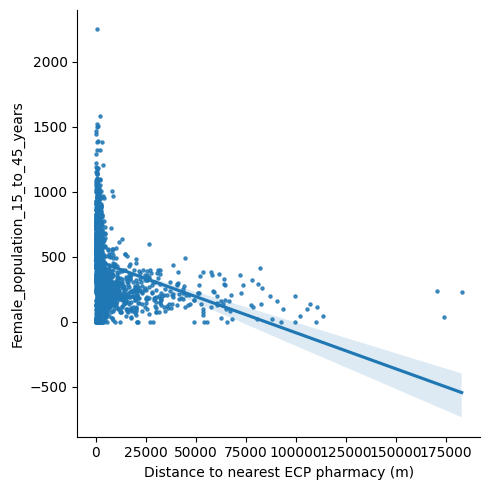

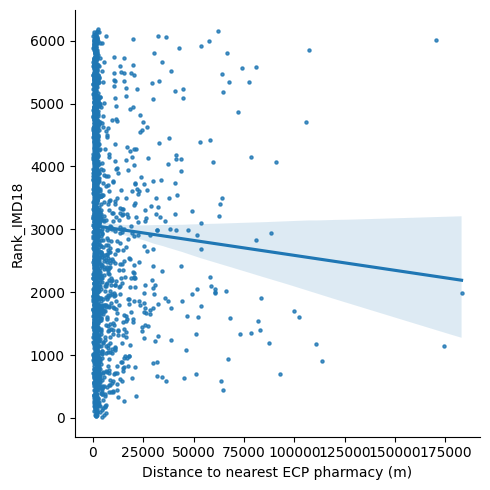

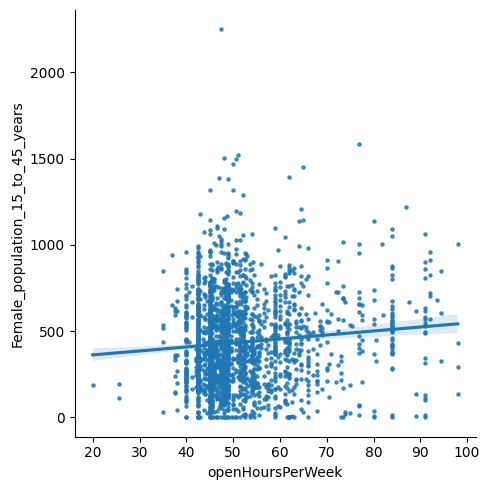

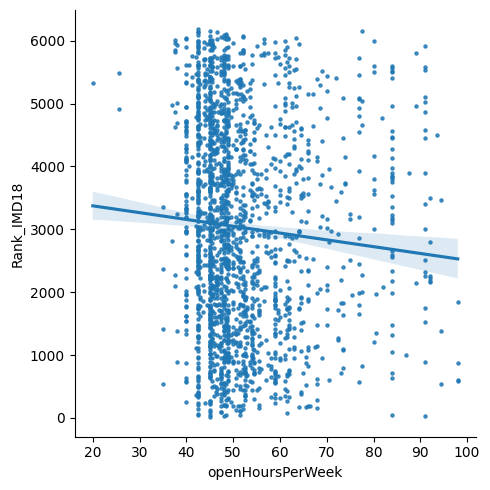

In [40]:
import seaborn as sns
sns.lmplot(x='Distance to nearest ECP pharmacy (m)',y='Female_population_15_to_45_years',data=sa2, scatter_kws={"s": 5})
sns.lmplot(x='Distance to nearest ECP pharmacy (m)',y='Rank_IMD18',data=sa2, scatter_kws={"s": 5})
sns.lmplot(x='openHoursPerWeek',y='Female_population_15_to_45_years',data=sa2, scatter_kws={"s": 5})
sns.lmplot(x='openHoursPerWeek',y='Rank_IMD18',data=sa2, scatter_kws={"s": 5})

,Distance to nearest pharmacy (m),Distance to nearest ECP pharmacy (m),Travel time to nearest pharmacy (s),Travel time to nearest ECP pharmacy (s),Nearest pharmacy name,Nearest ECP pharmacy name,Distance to nearest ECP pharmacy (km),Female_population_15_to_45_years
SA22023__1,,,,,,,,
East Cape,16280.6,170542.1,1771.1,9775.5,Te Araroa Collection Depot - Gordon's Pharmacy,Rauru Pharmacy,170.5421,237.0
Tokomaru,24369.7,107118.5,2803.0,7901.2,Te Puia Collection Depot - Gordon's Pharmacy,Rauru Pharmacy,107.1185,141.0
Wharekaka,20934.5,72077.5,2376.4,5268.6,Tolaga Bay Collection Depot - Gordon's Pharmacy,Rauru Pharmacy,72.0775,360.0
Waipaoa,30213.6,57941.3,3223.4,4754.9,Bramwell's Pharmacy Collection Depot - 59 Clif...,Gordon's Pharmacy,57.9413,381.0
Hangaroa,40903.2,40903.2,3370.5,3370.5,Sean Shivnan Pharmacy,Sean Shivnan Pharmacy,40.9032,282.0
Te Arai,11259.9,11259.9,873.8,873.8,Sean Shivnan Pharmacy,Sean Shivnan Pharmacy,11.2599,216.0
Hexton,6565.6,6565.6,566.7,566.7,Gordon's Pharmacy,Gordon's Pharmacy,6.5656,507.0
Wainui-Okitu,3943.6,3943.6,258.6,258.6,Rauru Pharmacy,Rauru Pharmacy,3.9436,351.0
Makaraka-Awapuni,3219.5,3219.5,317.9,317.9,Sean Shivnan Pharmacy,Sean Shivnan Pharmacy,3.2195,195.0


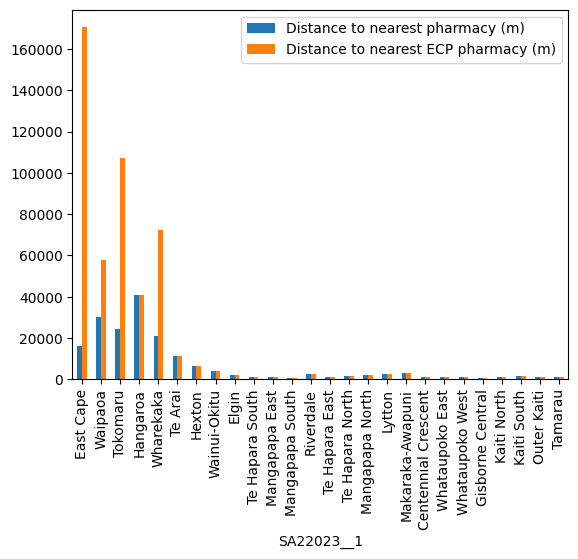

In [41]:
cols = ['Distance to nearest pharmacy (m)',
       'Distance to nearest ECP pharmacy (m)',
       'Travel time to nearest pharmacy (s)',
       'Travel time to nearest ECP pharmacy (s)', 'Nearest pharmacy name',
       'Nearest ECP pharmacy name', #'DHB', 'openHoursPerWeek',
       'Distance to nearest ECP pharmacy (km)',
       'Female_population_15_to_45_years']
sa2.index = sa2.SA22023__1
sa2.loc[sa2["DHB"] == "Tairāwhiti", ["Distance to nearest pharmacy (m)", "Distance to nearest ECP pharmacy (m)"]].plot.bar()
sa2.loc[sa2["DHB"] == "Tairāwhiti", cols].sort_values("Distance to nearest ECP pharmacy (m)", ascending=False)